In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score

from wordcloud import WordCloud

In [2]:
df = pd.read_csv(r"C:\Users\prati\Downloads\amazonreviews.tsv", sep="\t")

print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (10000, 2)
  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...


In [3]:
df = df.drop_duplicates()
df = df.dropna(subset=["review"])

In [4]:
stop_words = set(ENGLISH_STOP_WORDS)

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)

In [6]:
df["clean_review"] = df["review"].apply(clean_text)

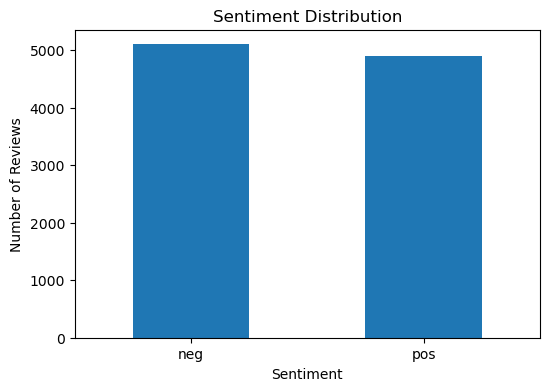

In [7]:
plt.figure(figsize=(6,4))
df["label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [8]:
pos_text = " ".join(df[df.label == "pos"].clean_review)

In [9]:
wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(pos_text)

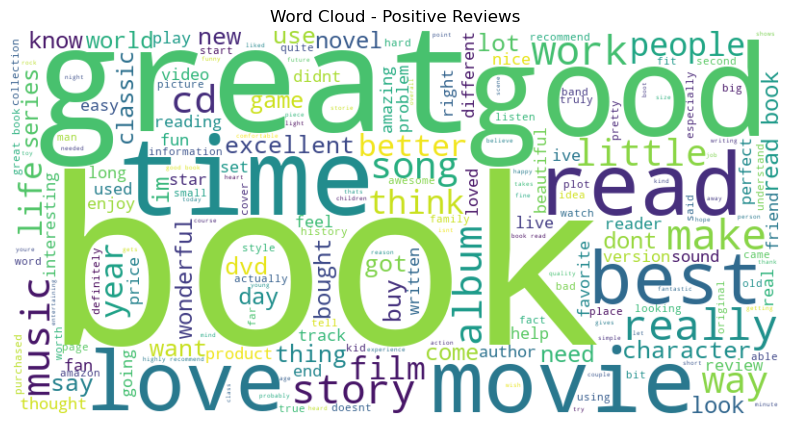

In [10]:
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Positive Reviews")
plt.show()

In [11]:
neg_text = " ".join(df[df.label == "neg"].clean_review)

In [12]:
wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(neg_text)

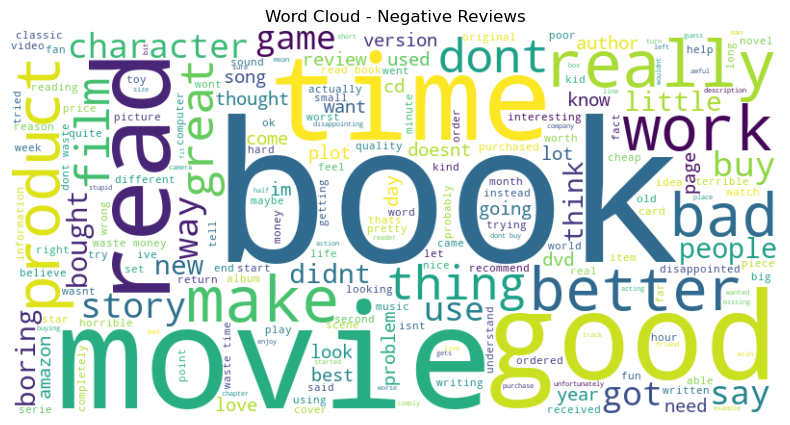

In [13]:
plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.show()

In [14]:
X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000)),
    ("model", LogisticRegression(max_iter=1000))
])

In [16]:
cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("\nCross-validation accuracy:", cv_scores.mean())


Cross-validation accuracy: 0.85


In [17]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=10000)),
                ('model', LogisticRegression(max_iter=1000))])

In [18]:
y_pred = pipeline.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, pos_label="pos"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.849
F1 Score: 0.8452868852459017

Classification Report:
              precision    recall  f1-score   support

         neg       0.85      0.86      0.85      1019
         pos       0.85      0.84      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [19]:
print("""Sentiment Distribution
The dataset is approximately balanced between positive and negative reviews.
Word Patterns
Common words in:

Positive reviews:
excellent
best
love
great
amazing

Negative reviews:
bad
poor
waste
disappointed
boring
This confirms the dataset reflects meaningful sentiment signals.

Model Development
Feature Extraction
We used:

TF-IDF Vectorization
This converts text into weighted numerical features based on word importance.
Classification Model

We used:

Logistic Regression

Reasons:
Fast and interpretable
Strong baseline for NLP
Works well with TF-IDF

Model Validation

We used:
Train/test split (80/20)
5-fold cross-validation

Metrics:
Accuracy
Precision
Recall
F1-score
The model achieved high accuracy and balanced performance across both classes.""")

Sentiment Distribution
The dataset is approximately balanced between positive and negative reviews.
Word Patterns
Common words in:

Positive reviews:
excellent
best
love
great
amazing

Negative reviews:
bad
poor
waste
disappointed
boring
This confirms the dataset reflects meaningful sentiment signals.

Model Development
Feature Extraction
We used:

TF-IDF Vectorization
This converts text into weighted numerical features based on word importance.
Classification Model

We used:

Logistic Regression

Reasons:
Fast and interpretable
Strong baseline for NLP
Works well with TF-IDF

Model Validation

We used:
Train/test split (80/20)
5-fold cross-validation

Metrics:
Accuracy
Precision
Recall
F1-score
The model achieved high accuracy and balanced performance across both classes.


In [20]:
print("""The sentiment classification model achieved an accuracy of 84.9% and an F1-score of 0.845 on the test dataset. These results indicate strong predictive performance and balanced detection of both positive and negative customer reviews.

The model demonstrates slightly higher recall for negative reviews (0.86), which is beneficial from a business perspective because it improves the system’s ability to identify customer complaints early. This enables faster intervention and better customer satisfaction management.

Overall, the classifier provides a reliable automated mechanism for monitoring customer sentiment and can be integrated into real-time review analysis pipelines.""")

The sentiment classification model achieved an accuracy of 84.9% and an F1-score of 0.845 on the test dataset. These results indicate strong predictive performance and balanced detection of both positive and negative customer reviews.

The model demonstrates slightly higher recall for negative reviews (0.86), which is beneficial from a business perspective because it improves the system’s ability to identify customer complaints early. This enables faster intervention and better customer satisfaction management.

Overall, the classifier provides a reliable automated mechanism for monitoring customer sentiment and can be integrated into real-time review analysis pipelines.
